#  `Pizza_Sales_Analysis`




## Overview:
- This project analyzes transactional sales data from a pizza store to uncover key insights and business trends.
-  The dataset includes details such as order ID, pizza name, category, size, quantity, price, and timestamps. 

## Objectives:
- Calculate total revenue, total pizzas sold, and total number of orders
- Analyze sales by pizza category and size
- Identify daily, hourly, and monthly sales trends
- Highlight best-selling and least-selling pizzas
- Measure customer behavior using Average Order Value (AOV) and 
  Average Pizzas per Order
- Provide visualizations for better decision-making





# _Import Libraries_ 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# _Importing Dataset_

In [2]:
df = pd.read_csv('../Pizza_Sales_Dataset/pizza_sales.csv')
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [3]:
df.tail()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,48620,21350,bbq_ckn_s,1,31-12-2015,23:02:05,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


# _Understand_The_Data_

In [4]:
print(df.columns)

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')


In [5]:
df.shape

(48620, 12)

In [6]:
# for rows
print("The Rows of  The Dataset: ",df.shape[0])

The Rows of  The Dataset:  48620


In [7]:
print("The columns of The Dataset: ",df.shape[1])

The columns of The Dataset:  12


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [9]:
df.info

<bound method DataFrame.info of        pizza_id  order_id  pizza_name_id  quantity  order_date order_time  \
0             1         1     hawaiian_m         1  01-01-2015   11:38:36   
1             2         2  classic_dlx_m         1  01-01-2015   11:57:40   
2             3         2  five_cheese_l         1  01-01-2015   11:57:40   
3             4         2    ital_supr_l         1  01-01-2015   11:57:40   
4             5         2     mexicana_m         1  01-01-2015   11:57:40   
...         ...       ...            ...       ...         ...        ...   
48615     48616     21348  ckn_alfredo_m         1  31-12-2015   21:23:10   
48616     48617     21348  four_cheese_l         1  31-12-2015   21:23:10   
48617     48618     21348   napolitana_s         1  31-12-2015   21:23:10   
48618     48619     21349     mexicana_l         1  31-12-2015   22:09:54   
48619     48620     21350      bbq_ckn_s         1  31-12-2015   23:02:05   

       unit_price  total_price pizza_size p

# _Data_Types_

In [10]:
# Data_Types
df.dtypes

pizza_id               int64
order_id               int64
pizza_name_id         object
quantity               int64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object

In [11]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


# _Check_Missing_Values_

In [12]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [13]:
df.isnull().sum().sum()

np.int64(0)

# _Check_Duplicated_Values_

In [14]:
df.duplicated().sum()

np.int64(0)

# _Key_Performance_Indicators_
- Total Revenue 
- Total Pizzas Sold 
- Total Orders 
- Average Order Value (AOV) 
- Average Pizza per Order 

In [15]:
Total_revenue = df['total_price'].sum()
Total_Pizzas_Sold = df['quantity'].sum()
Total_Orders = df['order_id'].nunique()
Average_Order_Value = Total_revenue / Total_Orders
Average_Pizza_per_Order  = Total_Pizzas_Sold / Total_Orders

In [16]:
print(f"Total Revenue :             ${Total_revenue:,.2f}")
print(f"Total Pizzas Sold :          {Total_Pizzas_Sold:,}")
print(f"Total Orders :               {Total_Orders:,.2f}")
print(f"Average Order Value  :      ${Average_Order_Value:,.2f}")
print(f"Average Pizza per Order:     {Average_Pizza_per_Order:,.2f}")

Total Revenue :             $817,860.05
Total Pizzas Sold :          49,574
Total Orders :               21,350.00
Average Order Value  :      $38.31
Average Pizza per Order:     2.32


# _Data_Visualization_

- Ingredient Analysis

In [17]:
ingredients = (
    df['pizza_ingredients']
    .str.split(',')
    .explode().str.strip()
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'count', 'pizza_ingredients': 'ingredients'})
)


In [18]:
print(ingredients)

           ingredients  count
0               Garlic  27422
1             Tomatoes  26601
2           Red Onions  19547
3          Red Peppers  16284
4    Mozzarella Cheese  10333
..                 ...    ...
60   Brie Carre Cheese    480
61          Prosciutto    480
62  Caramelized Onions    480
63               Pears    480
64               Thyme    480

[65 rows x 2 columns]


In [19]:
ingredients.head(10)

,ingredients,count
0,Garlic,27422
1,Tomatoes,26601
2,Red Onions,19547
3,Red Peppers,16284
4,Mozzarella Cheese,10333
5,Pepperoni,10300
6,Spinach,10012
7,Mushrooms,9624
8,Chicken,8443
9,Capocollo,6572


# _Trends_

- Daily_Trend -> Total Orders

In [20]:

df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['day_name'] = df['order_date'].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

orders_by_day = df.groupby('day_name', observed=False)['order_id'].nunique()
orders_by_day = orders_by_day.sort_index()


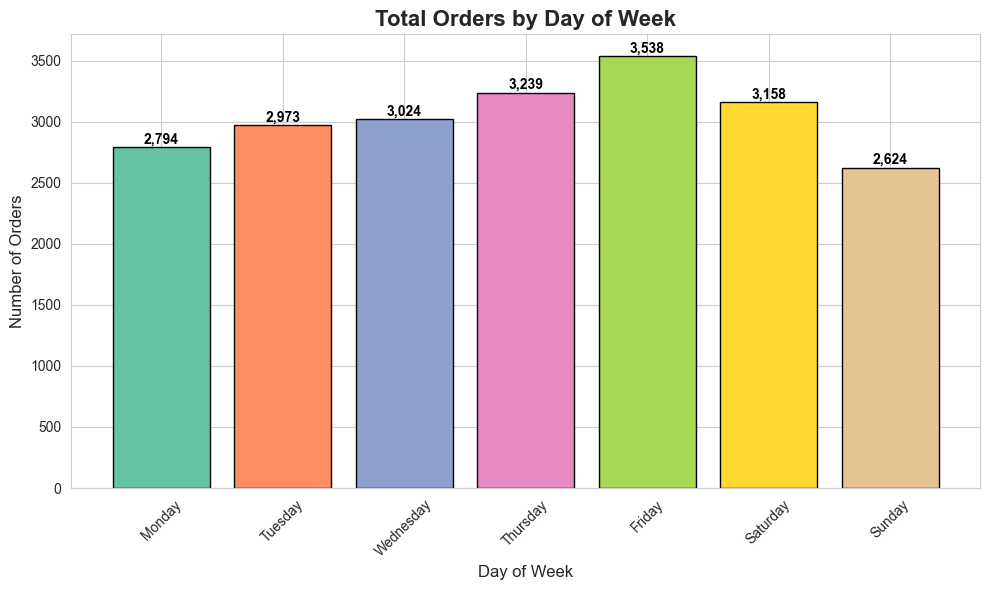

In [21]:
sns.set_style("whitegrid")
palette = sns.color_palette("Set2")

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(orders_by_day.index, orders_by_day.values, color=palette, edgecolor='black')

plt.title("Total Orders by Day of Week", fontsize=16, fontweight='bold')
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 5, f'{height:,}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


- Daily_Trend -> Total Revenue

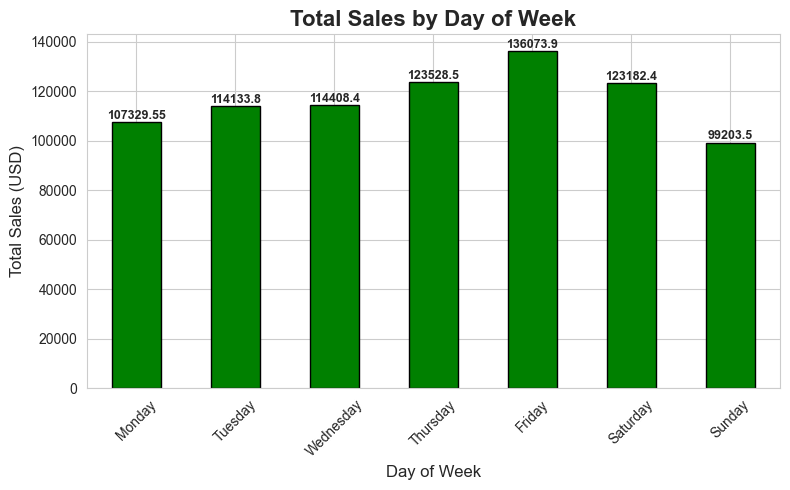

In [22]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['day_name'] = df['order_date'].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

orders_by_day = df.groupby('day_name', observed=False)['total_price'].sum()

ax = orders_by_day.plot(kind='bar', figsize=(8,5), color="green", edgecolor='black')

plt.title("Total Sales by Day of Week", fontsize=16, fontweight='bold')
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Total Sales (USD)", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

for i, val in enumerate(orders_by_day):
    plt.text(i, val + 20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# _Hourely_Trend_

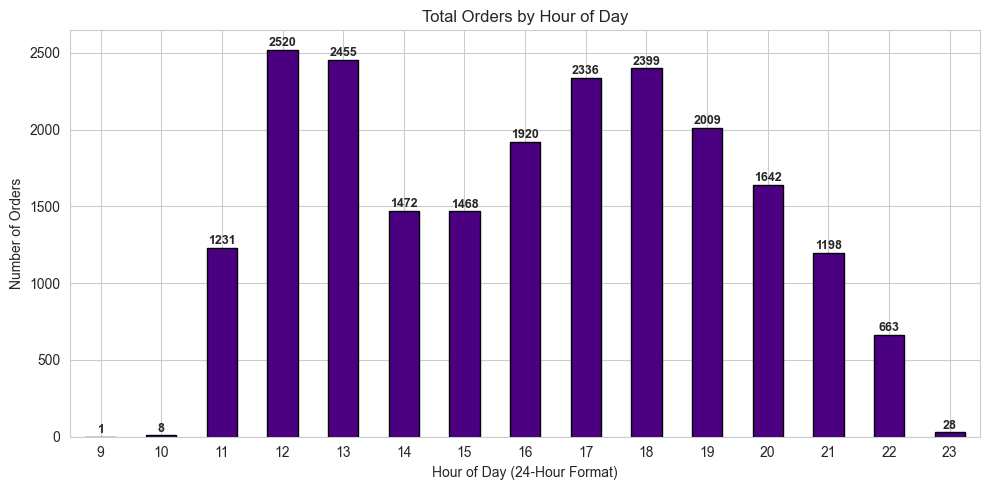

In [23]:
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

df['order_hour'] = df['order_time'].dt.hour

orders_by_hour = df.groupby('order_hour', observed=False)['order_id'].nunique()

ax = orders_by_hour.plot(kind='bar', figsize=(10,5), color='Indigo', edgecolor='black')

plt.title("Total Orders by Hour of Day")
plt.xlabel("Hour of Day (24-Hour Format)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

for i, val in enumerate(orders_by_hour):
    plt.text(i, val + 5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# _Monthly_Trend_

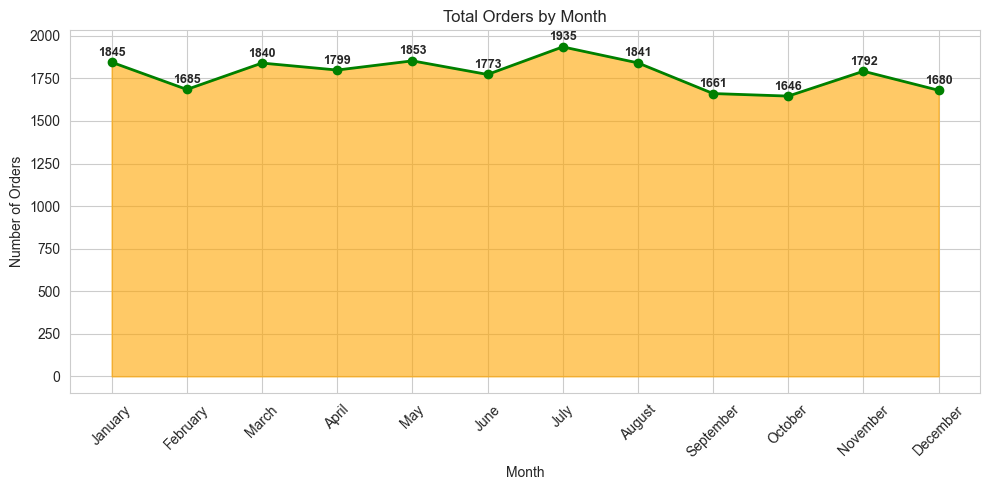

In [24]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['month_name'] = df['order_date'].dt.month_name()

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

orders_by_month = df.groupby('month_name', observed=False)['order_id'].nunique()

plt.figure(figsize=(10,5))
plt.fill_between(orders_by_month.index, orders_by_month.values, color="orange", alpha=0.6)
plt.plot(orders_by_month.index, orders_by_month.values, color="green", linewidth=2, marker='o')

plt.title("Total Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_month):
    plt.text(i, val + 20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# Sales_Category_Percentage

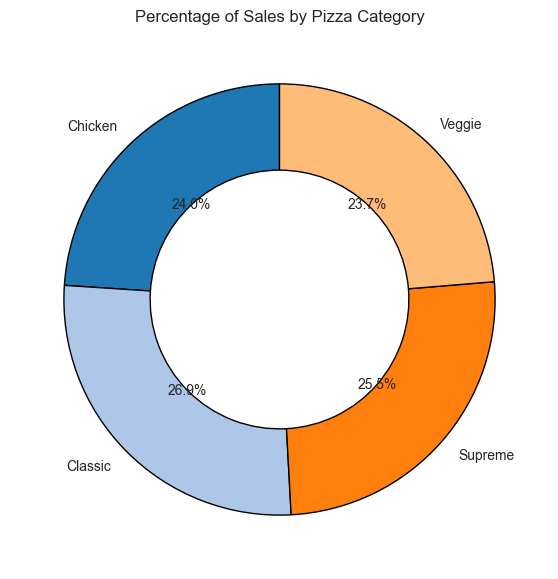

In [25]:
category_sales = df.groupby('pizza_category')['total_price'].sum()

category_pct = category_sales / category_sales.sum() * 100

plt.figure(figsize=(7, 7))
colors = plt.get_cmap('tab20').colors  
plt.pie(category_pct, labels=category_pct.index, autopct='%1.1f%%', startangle=90, 
        colors=colors, wedgeprops={'edgecolor':'black', 'width':0.4})

plt.title("Percentage of Sales by Pizza Category")
plt.show()


# _Heatmap_

In [26]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


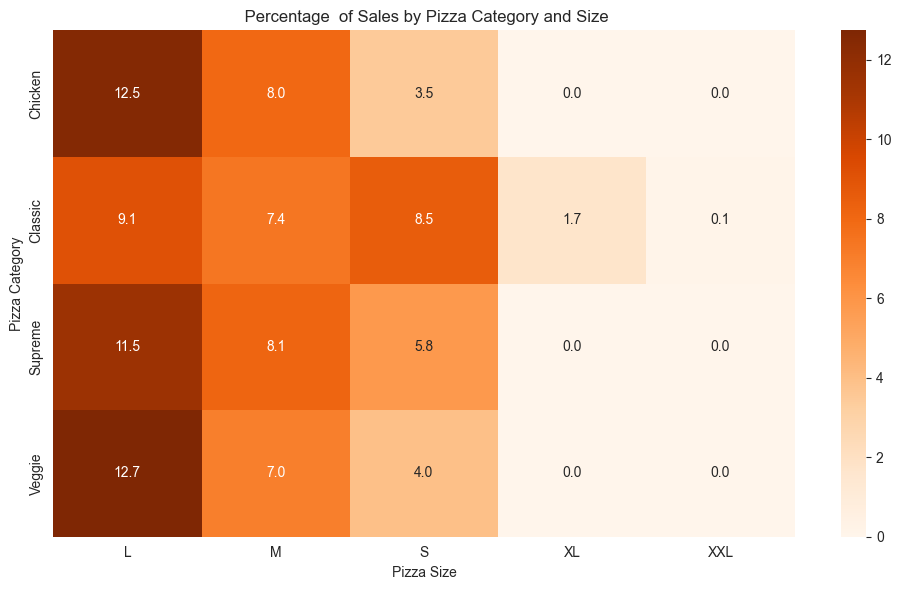

In [27]:

sales_pivot = df.pivot_table(
    index='pizza_category',
    columns='pizza_size',
    values='total_price',
    aggfunc='sum',
    fill_value=0
)

sales_pct = sales_pivot / sales_pivot.sum().sum() * 100

plt.figure(figsize=(10, 6))
sns.heatmap(
    sales_pct,
    annot=True,
    fmt=".1f",
    cmap="Oranges",
    linecolor="white"
)

plt.title(" Percentage  of Sales by Pizza Category and Size")
plt.xlabel("Pizza Size")
plt.ylabel("Pizza Category")
plt.tight_layout()
plt.show()


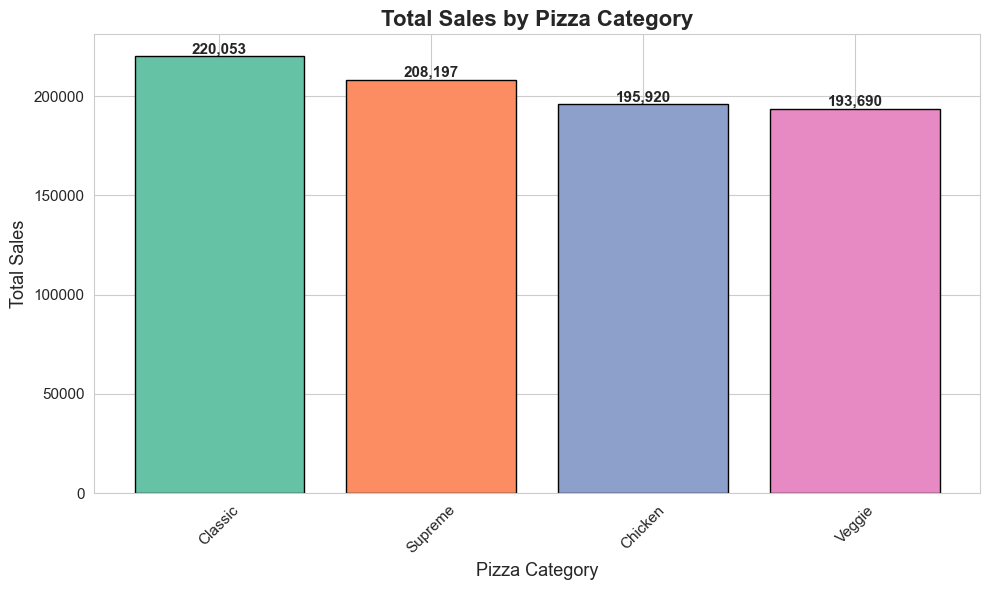

In [28]:
import matplotlib.pyplot as plt

# Group total sales by pizza category
category_sales = df.groupby('pizza_category')['total_price'].sum().sort_values(ascending=False)

# Create a color palette with unique colors
colors = plt.cm.Set2(range(len(category_sales)))

# Plot bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(category_sales.index, category_sales.values, color=colors, edgecolor='black')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:,.0f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Styling
plt.title("Total Sales by Pizza Category", fontsize=16, fontweight='bold')
plt.xlabel("Pizza Category", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


# Top 10 Best-Selling Pizza Products by Total Sales

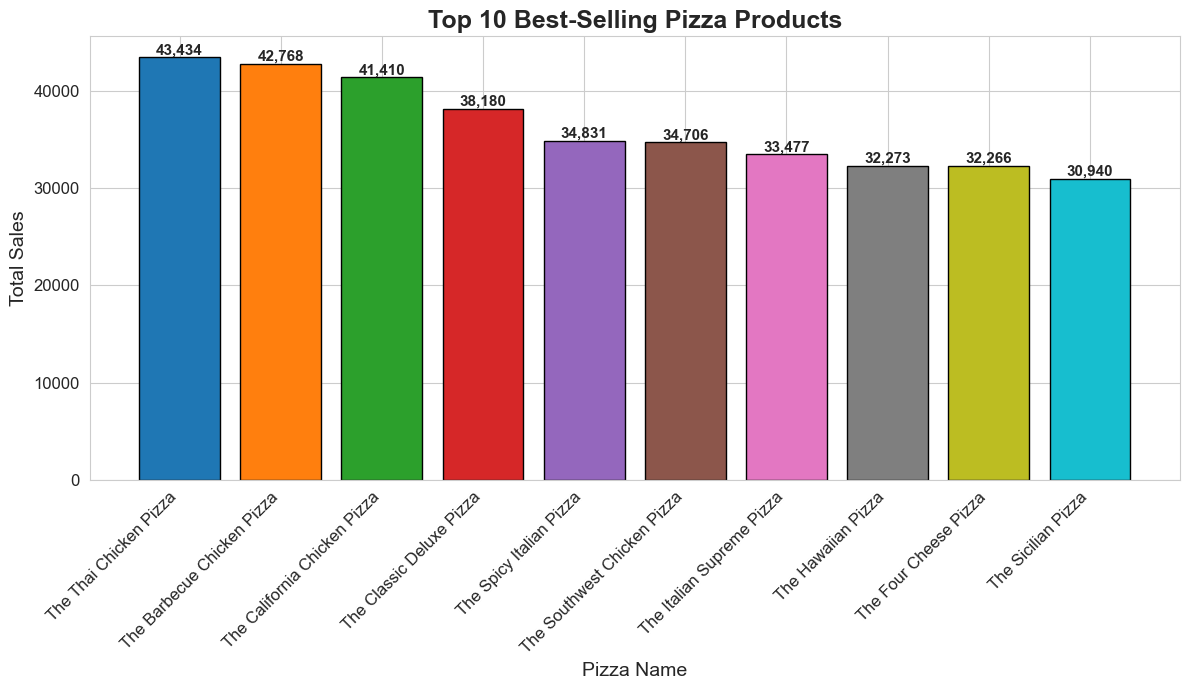

In [29]:

top_10 = df.groupby('pizza_name')['total_price'].sum().sort_values(ascending=False).head(10)

colors = plt.cm.tab10(range(10))

plt.figure(figsize=(12, 7))
bars = plt.bar(top_10.index, top_10.values, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Top 10 Best-Selling Pizza Products", fontsize=18, fontweight='bold')
plt.xlabel("Pizza Name", fontsize=14)
plt.ylabel("Total Sales", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
